# Cloud satellite estimation (clean)

Reproduces the analysis in `cloud_satellite.ipynb` using the `goesclouds`
module. Every cell is one or two calls into `goesclouds`; intermediate
DataFrames live as notebook variables so they can be inspected directly.
See `goesclouds.md` for the full design and `goesclouds.py` for the
implementation.

In [1]:
%load_ext autoreload
%autoreload 1
%aimport goesclouds
import goesclouds as gc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

gc.configure_notebook_logging()

## Configure cache

Set to `None` to not use the cache.

In [2]:
sample_quarter_cache = 'sample_goes.h5'
missing_quarter_cache = 'missing_goes.h5'

## Get quarters of interest

In [3]:
missing_year = 2015

quarter_reports  = gc.load_quarter_reports()
sample_quarters  = gc.select_sample_quarters(quarter_reports)
missing_quarters = gc.select_missing_quarters(quarter_reports, year=missing_year)

## Create cache of samples

In [4]:
window_size = gc.DEFAULT_WINDOW_SIZE
bands = (gc.DEFAULT_BAND, gc.CORRECTION_BAND)
bands = [6]

In [5]:
sample_quarter_cache = 'sample_goes.h5'

def sample_goes_key(band, window_size=gc.DEFAULT_WINDOW_SIZE):
    return f'sample_band_{band}_window_{window_size}'

for band in bands:
    key = sample_goes_key(band, window_size)
    with pd.HDFStore(sample_quarter_cache, mode="r") as store:
        if key in store:
            continue
    these_samples = gc.extract_band_samples(sample_quarters, band=band, window_size=window_size)
    these_samples.to_hdf(sample_quarter_cache, key=key)

In [6]:
missing_years = missing_quarters.reset_index().year.unique().tolist()

def missing_goes_key(year, band, window_size=gc.DEFAULT_WINDOW_SIZE):
    return f'missing_{year}_band_{band}_window_{window_size}'

for year in missing_years:
    for band in bands:
        key = missing_goes_key(year, band, window_size)
        try:
            with pd.HDFStore(missing_quarter_cache, mode="r") as store:
                if key in store:
                    continue
        except FileNotFoundError:
            pass
        these_samples = gc.extract_band_samples(missing_quarters, band=band, window_size=window_size)
        these_samples.to_hdf(missing_quarter_cache, key=key)

## Load and sample

In [7]:
quarter_reports  = gc.load_quarter_reports()
sample_quarters  = gc.select_sample_quarters(quarter_reports)
missing_quarters = gc.select_missing_quarters(quarter_reports, year=2015)
len(quarter_reports), len(sample_quarters), len(missing_quarters)

(69652, 891, 180)

## Single-band analysis

Pixel samples for one band, summary stats, and the per-quarter
brightness-based cloud-eighths estimate.

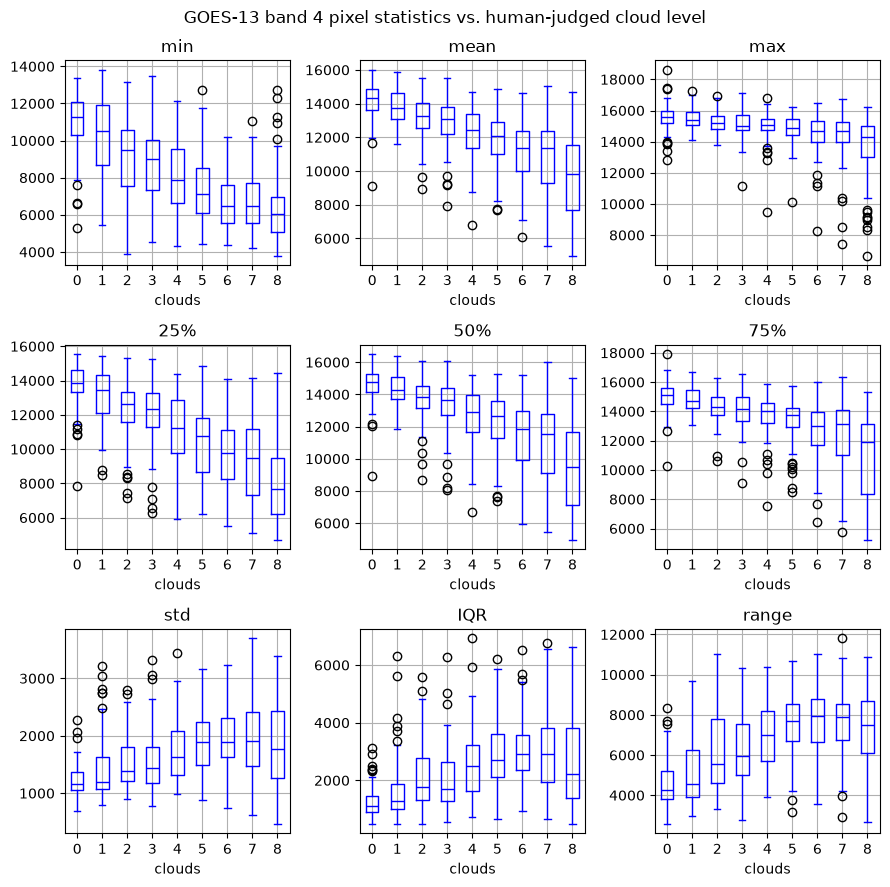

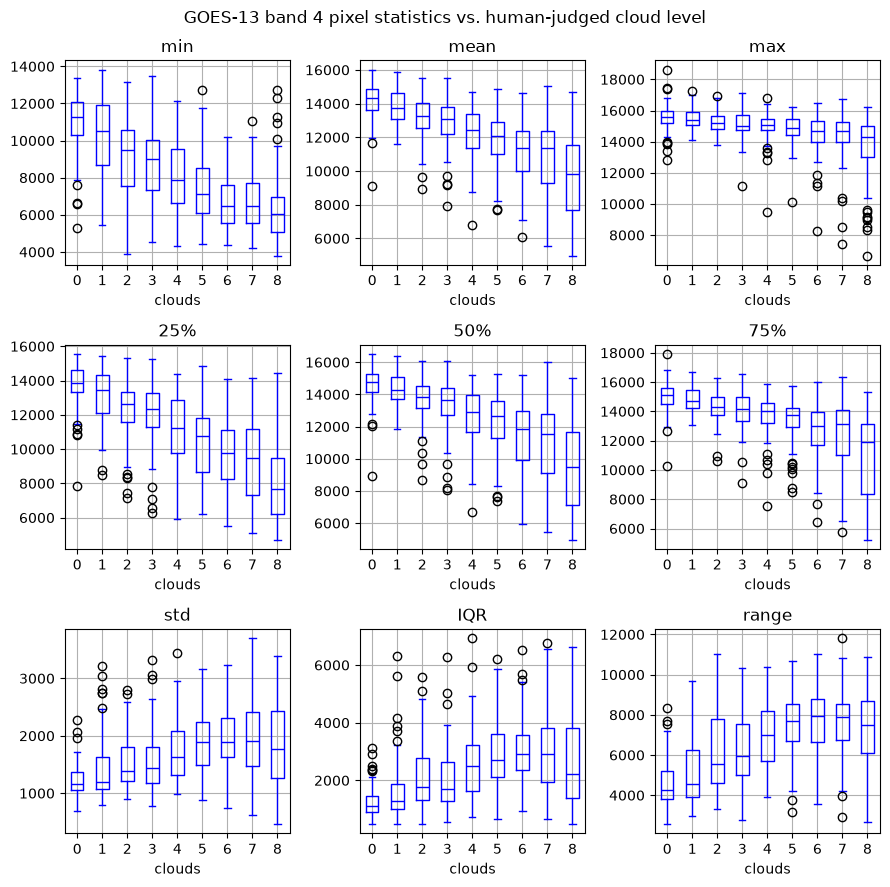

In [8]:
band = 4
if sample_quarter_cache is None:
    band_samples = gc.extract_band_samples(sample_quarters, band=band)
else:
    key = sample_goes_key(band)
    band_samples = pd.read_hdf(sample_quarter_cache, key)

stats = gc.compute_sample_stats(band_samples)
gc.plot_sample_stats(stats, band=band)

12576

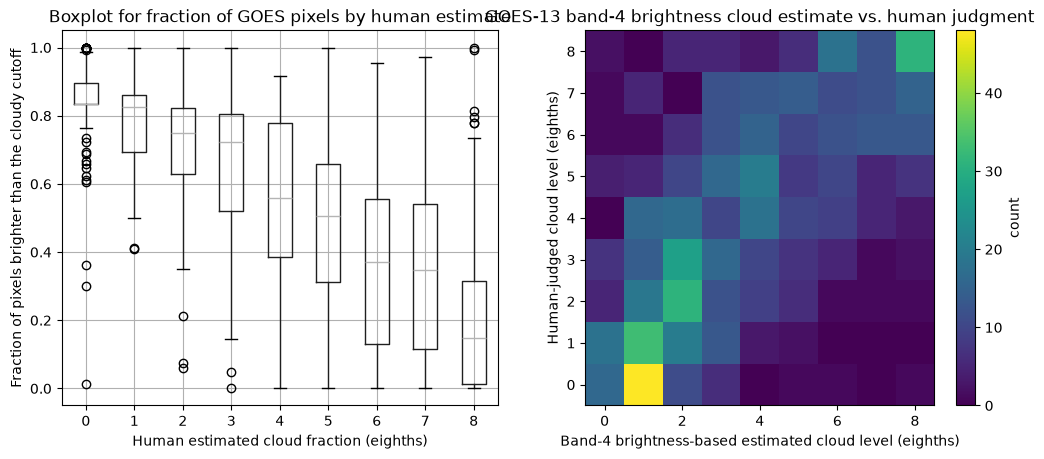

In [9]:
#cloudcut   = gc.reference_quantile(band_samples, f"band{band}")
cloudcut   = gc.optimize_cloudcut_obs(band_samples, f"band{band}")
by_quarter = gc.compute_by_quarter(band_samples, f"band{band}", cloudcut)
gc.plot_by_quarter(by_quarter, band=band)
cloudcut

## Fill missing quarters, one band

`cloudcut` comes from the calibration sample and is reused, unchanged, for
the 2015 quarters with a missing human report.

PosixPath('satellite_clouds_band4_2015.txt')

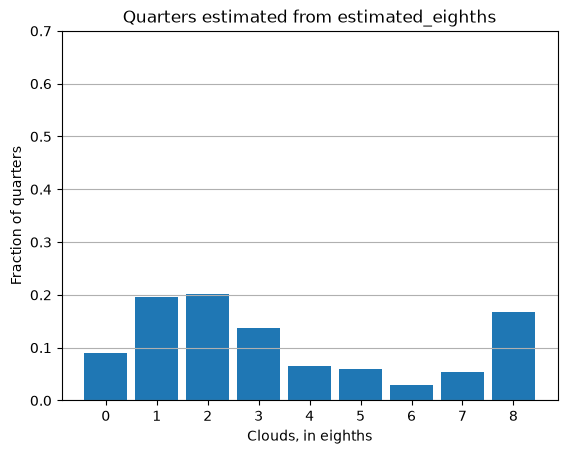

In [10]:
if missing_quarter_cache is None:
    missing_samples = gc.extract_band_samples(missing_quarters, band=band)
else:
    key = missing_goes_key(missing_year, band)
    missing_samples = pd.read_hdf(missing_quarter_cache, key)

missing_by_quarter = gc.compute_by_quarter(missing_samples, f"band{band}", cloudcut)
gc.plot_estimate_histogram(missing_by_quarter)
gc.write_band_estimates(missing_by_quarter, f"satellite_clouds_band{band}_2015.txt")

## Multi-band comparison

Join bands 2, 4, and 6 into one pixel-indexed frame, then build the
`(band, stat)`-columned `sample_stats` frame as per-band
`compute_sample_stats` + `pd.concat` (there is no
`compute_sample_stats_multiband` -- see `goesclouds.md` §7.4).

In [11]:
multiband = gc.load_multiband_samples(sample_quarters, bands=(2, 4, 6))

human_clouds = None
band_stat_frames = {}
for b in (2, 4, 6):
    band_values = gc.as_value_frame(multiband, (b, "value"))
    s = gc.compute_sample_stats(band_values, value_column="value")
    human_clouds = s["clouds"]
    del s["clouds"]
    s.columns = pd.MultiIndex.from_product([[b], s.columns])
    band_stat_frames[b] = s
multiband_stats = pd.concat(band_stat_frames.values(), axis=1)
multiband_stats[("human", "clouds")] = human_clouds

2026-09-16 17:06:12,150 - WARNING - skipping /media/psf/aisandbox/rubin_sim_notebooks/clouds/data/satellite_2013-09-02_q2/GOES13_2_2013-09-10T233725.nc: timestamp 2013-09-10 23:37:25 is more than 2 day(s) outside the quarter window [2013-09-03 02:05:55, 2013-09-03 04:42:08]
2026-09-16 17:06:12,152 - WARNING - skipping /media/psf/aisandbox/rubin_sim_notebooks/clouds/data/satellite_2013-09-04_q2/GOES13_2_2013-09-10T235229.nc: timestamp 2013-09-10 23:52:29 is more than 2 day(s) outside the quarter window [2013-09-05 02:06:06, 2013-09-05 04:41:29]
2026-09-16 17:06:12,156 - WARNING - skipping /media/psf/aisandbox/rubin_sim_notebooks/clouds/data/satellite_2013-09-04_q3/GOES13_2_2013-09-10T235229.nc: timestamp 2013-09-10 23:52:29 is more than 2 day(s) outside the quarter window [2013-09-05 04:41:29, 2013-09-05 07:16:52]
2026-09-16 17:06:12,159 - WARNING - skipping /media/psf/aisandbox/rubin_sim_notebooks/clouds/data/satellite_2013-09-07_q3/GOES13_2_2013-09-11T022532.nc: timestamp 2013-09-11 0

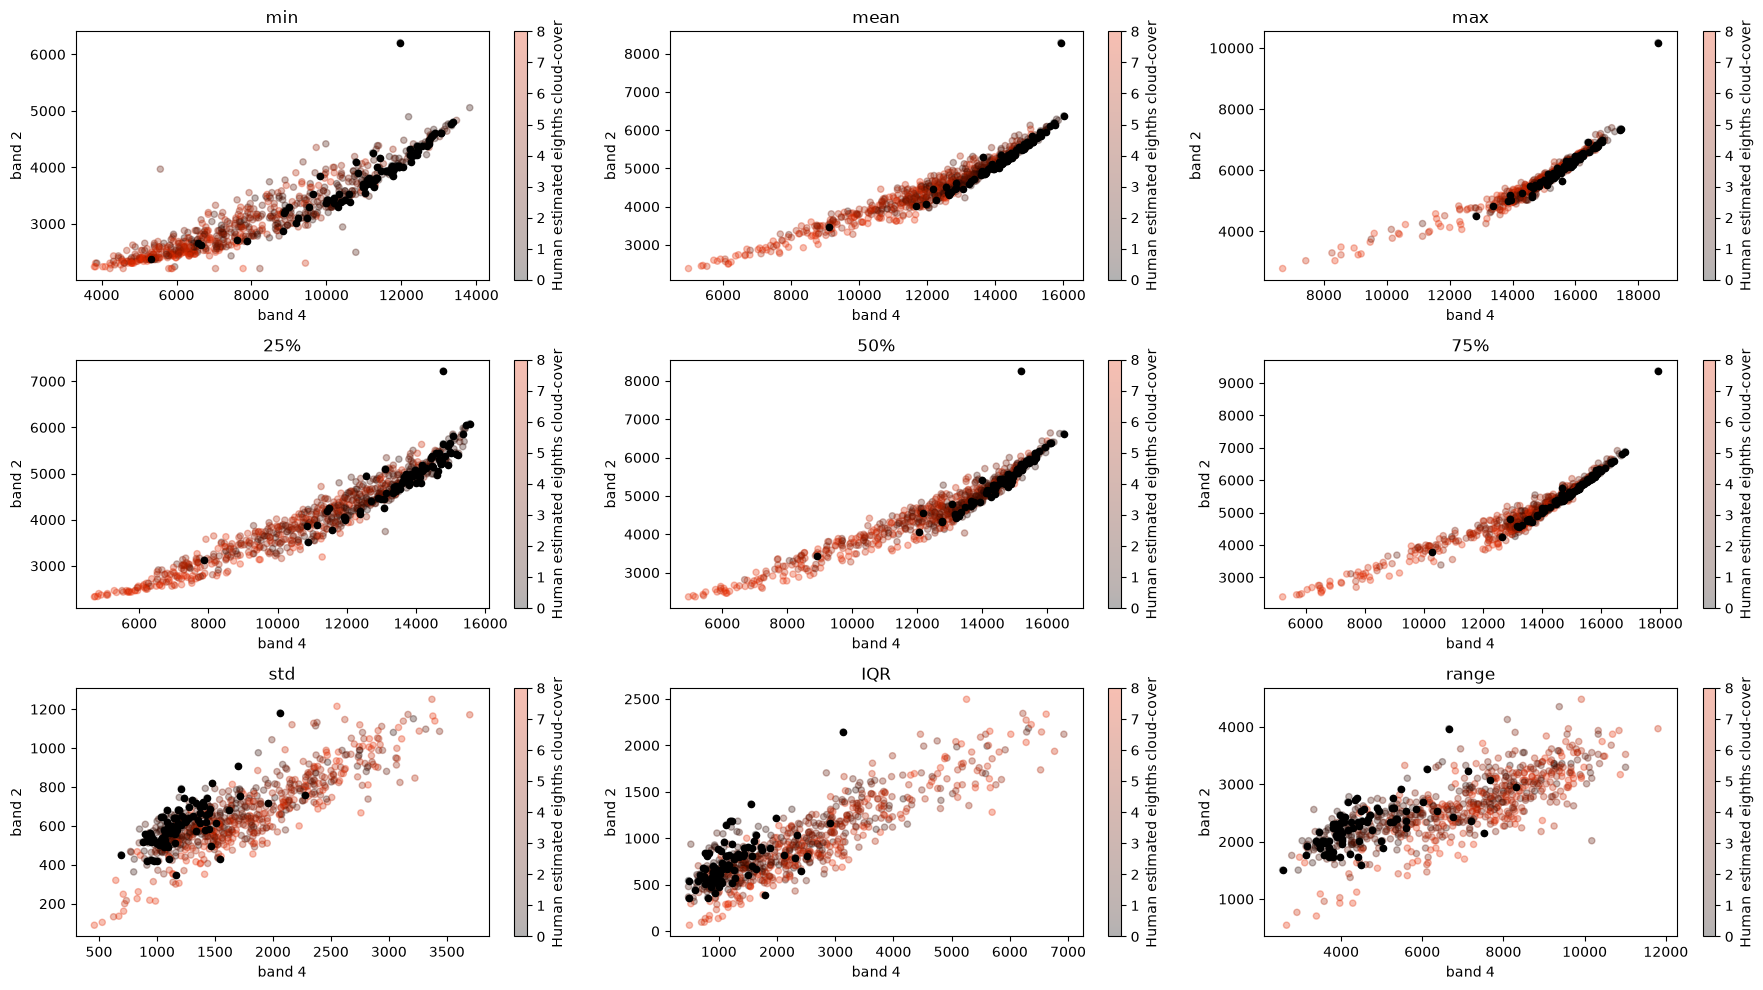

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
clear = multiband_stats[("human", "clouds")] == 0
for stat_name, ax in zip(gc.STAT_NAMES, axes.flatten()):
    gc.plot_band_comparison(multiband_stats, stat_name, ax, 4, 2, clear_mask=clear)
fig.tight_layout()

## Band-2-corrected estimator

Fit a per-pixel clear-sky relation of band 4 against band 2, and use it
to correct band-4 brightness for each pixel's own clear-sky baseline.

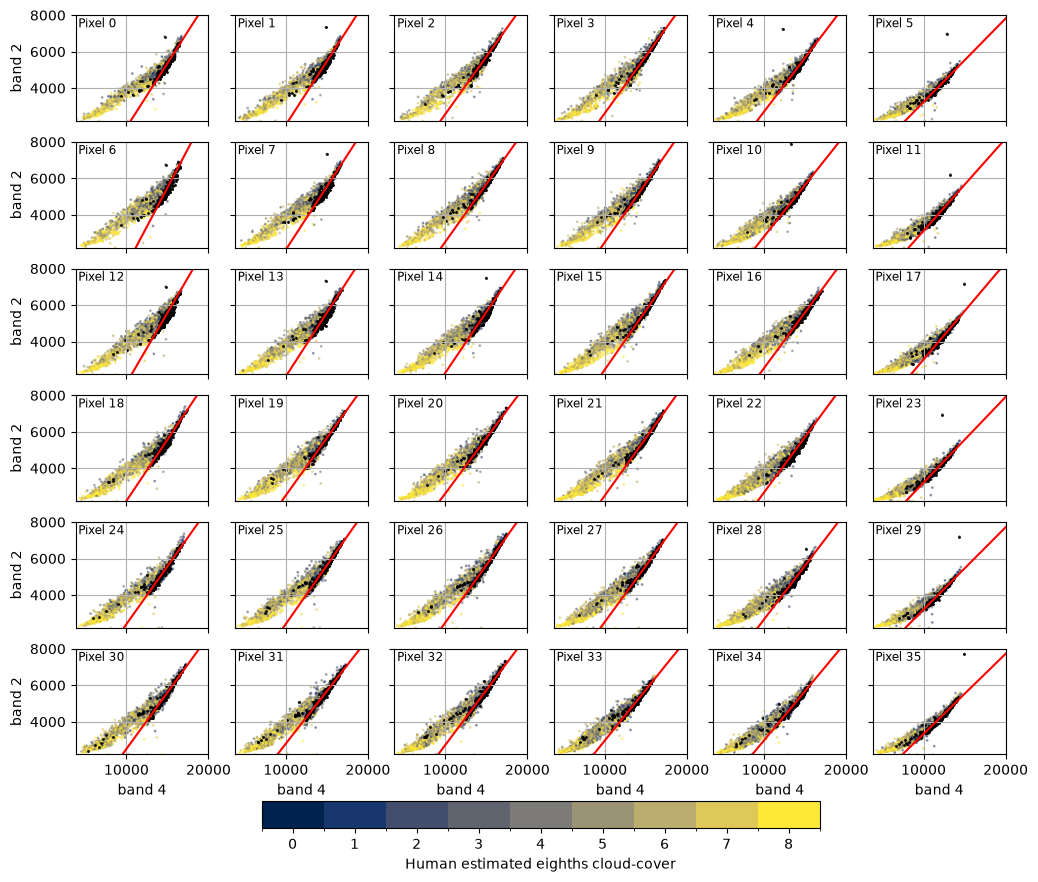

In [13]:
models    = gc.fit_clear_sky_model(multiband, x_band=2, y_band=4, per_pixel=True)
corrected = gc.apply_clear_sky_correction(multiband, models, x_band=2, y_band=4)
fig = gc.plot_per_pixel_models(corrected, models, x_band=4, y_band=2)
fig.savefig('clear_band2_vs_band4_by_pixel.png')
None

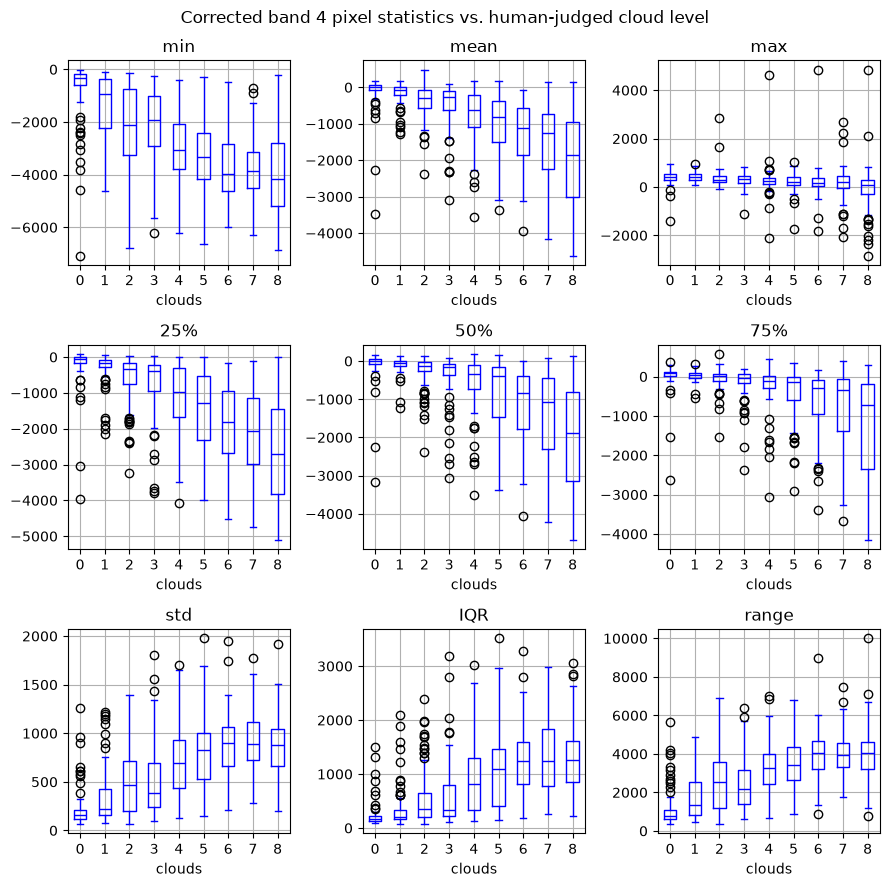

In [14]:
norm_samples = gc.as_value_frame(corrected, ('4corr', 'value'))
stats        = gc.compute_sample_stats(norm_samples, value_column='value')
_ = gc.plot_sample_stats(stats, title="Corrected band 4 pixel statistics vs. human-judged cloud level")

In [15]:
candidates = np.sort(norm_samples['value'].dropna().unique())
candidates = candidates[candidates < 0]
candidates = candidates[candidates > norm_samples.loc[norm_samples.clouds == 5, 'value'].median()]

In [16]:
%%time
#norm_samples  = gc.as_value_frame(corrected, ("4corr", "value"))
#norm_cloudcut = gc.reference_quantile(norm_samples, "value")
candidates = np.sort(norm_samples.value.dropna().astype(int).unique())
norm_cloudcut = gc.optimize_cloudcut_obs(norm_samples, "value", candidates=candidates)
norm_by_q     = gc.compute_by_quarter(norm_samples, "value", norm_cloudcut)

CPU times: user 2min 47s, sys: 169 ms, total: 2min 47s
Wall time: 2min 49s


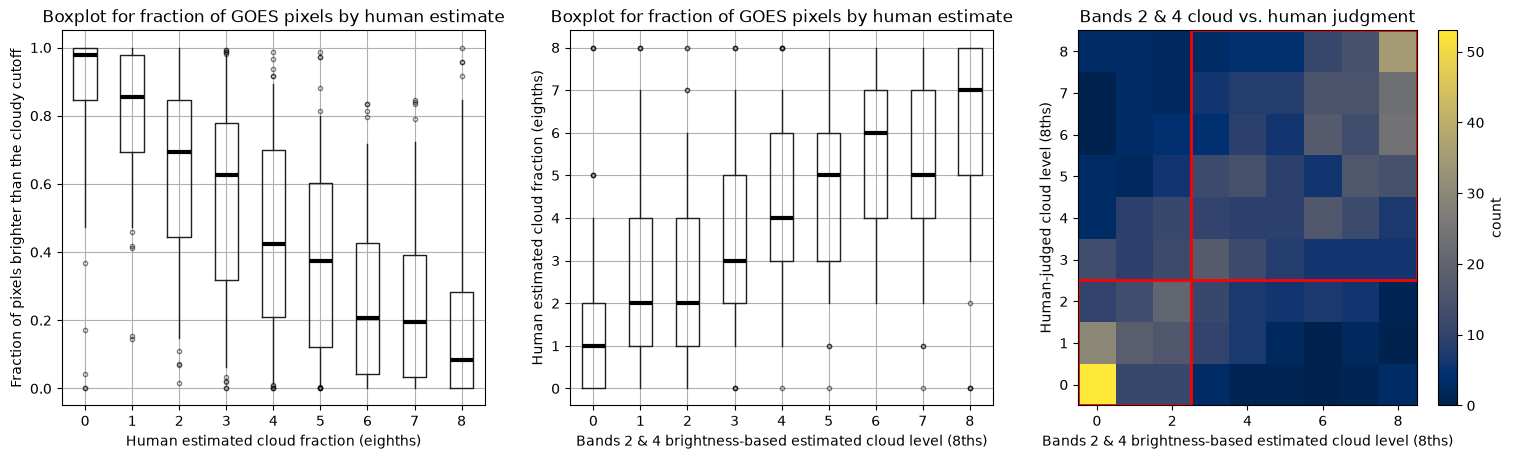

In [17]:
fig = gc.plot_norm_by_quarter(norm_by_q)
fig.savefig('pred_by_quarter.png')

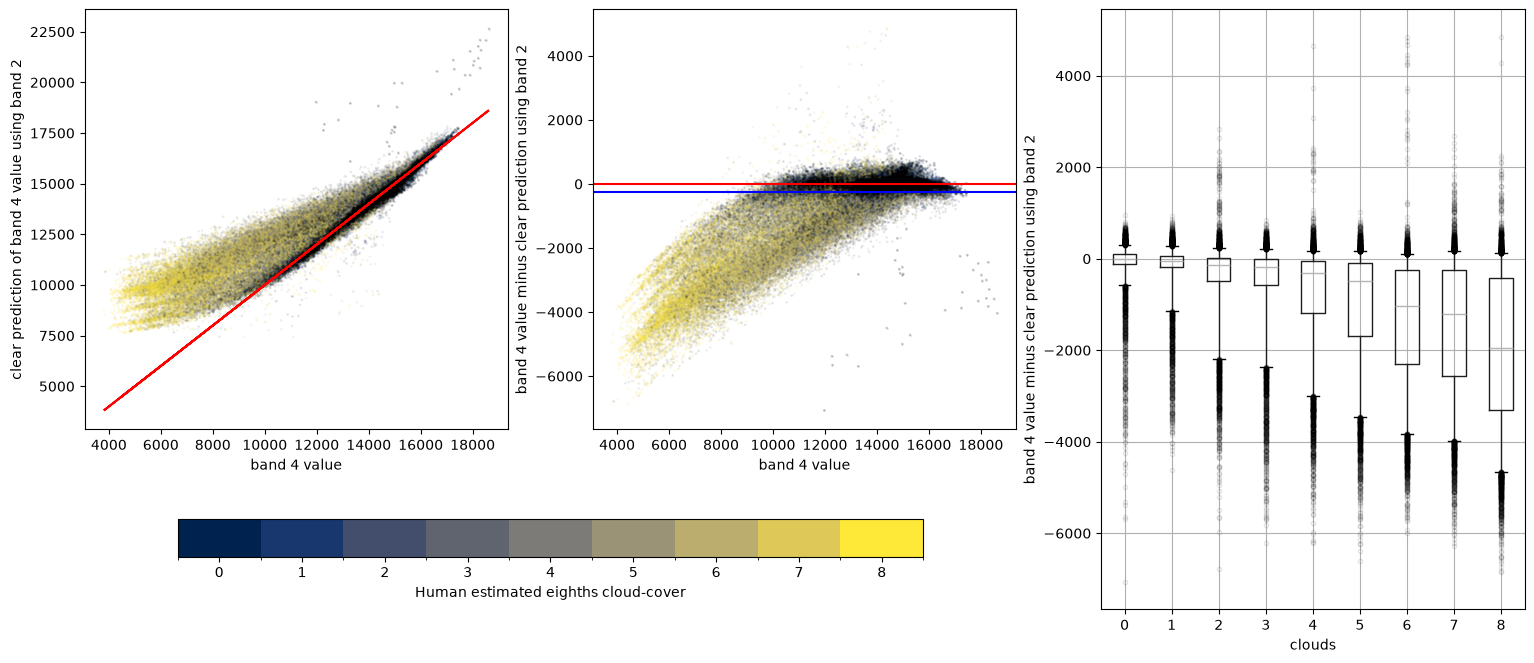

In [18]:
fig = gc.plot_clear_sky_model(corrected, "value", x_band=2, y_band=4, cloudcut=norm_cloudcut)
fig.savefig('clear_sky_model.png')
None

## Comparing estimators

Per-band brightness cuts vs. the band-2-corrected cut, scored against
the human quarter reports.

In [19]:
by_quarter_per_band = {}
b_cloudcut = {}
for b in (2, 4, 6):
    b_samples = gc.as_value_frame(multiband, (b, "value"))
    b_cloudcut[b] = gc.optimize_cloudcut_obs(b_samples, "value")
    by_quarter_per_band[b] = gc.compute_by_quarter(b_samples, "value", b_cloudcut[b])

match_stats = gc.compare_estimates(multiband, {
    "cut on 2": by_quarter_per_band[2],
    "cut on 4": by_quarter_per_band[4],
    "cut on 6": by_quarter_per_band[6],
    "cut on 4 corrected by 2": norm_by_q,
})
for b in (2, 4, 6):
    match_stats.loc[f"cut on {b}", 'cloudcut'] = b_cloudcut[b]

match_stats.loc["cut on 4 corrected by 2", 'cloudcut'] = norm_cloudcut
match_stats

,n,n_exact,n_match_obs,human_mean_eighths,estimated_mean_eighths,frac_match_obs,cloudcut
cut on 2,746.0,160.0,560.0,3.941019,4.630027,0.750670,4832.0
cut on 4,768.0,177.0,590.0,3.955729,3.533854,0.768229,12576.0
cut on 6,768.0,161.0,594.0,3.955729,4.446615,0.773438,15488.0
cut on 4 corrected by 2,746.0,193.0,590.0,3.941019,3.998660,0.790885,-243.0


## Missing quarters, corrected

Apply the calibration-sample models to the 2015
quarters with a missing human report -- the models and `norm_cloudcut` come
from calibration; only the eighths come from the missing-quarter data.

PosixPath('satellite_clouds_4corr2_2015.txt')

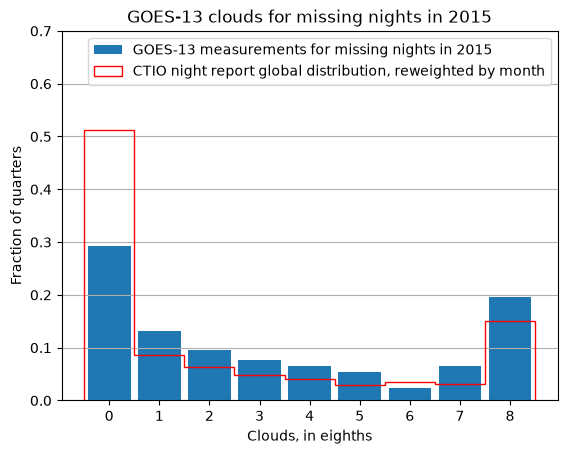

In [20]:
missing_multiband = gc.load_multiband_samples(missing_quarters, bands=(2, 4))
missing_corrected = gc.apply_clear_sky_correction(missing_multiband, models, x_band=2, y_band=4)
missing_norm      = gc.compute_by_quarter(
    gc.as_value_frame(missing_corrected, ("4corr", "value")), "value", norm_cloudcut,
)
fig = gc.plot_estimate_histogram(
    missing_norm,
    quarter_reports=quarter_reports,
    title="GOES-13 clouds for missing nights in 2015"
)
fig.savefig("missing2015dist.png")
gc.write_band_estimates(
    missing_norm,
    "satellite_clouds_4corr2_2015.txt",
    columns=["year", "month", "sday", "quarter", "estimated_eighths", "fraction_above_cloudcut"]
)


## Save estimates

In [21]:
window_size = gc.DEFAULT_WINDOW_SIZE
hdf5_key = f'window{window_size}'
norm_by_q.to_hdf('fit_quarters.h5', key=hdf5_key)
missing_norm.to_hdf('missing_2015.h5', key=hdf5_key) 

### Compare sample estimates

In [22]:
nbqs = []
for w in (4, 6, 8, 10):
    try:
        this_nbq = pd.read_hdf('fit_quarters.h5', key=f'window{w}')
        this_nbq.columns = pd.MultiIndex.from_product([[w], this_nbq.columns])
        this_nbq.columns.names = ['window', 'value']
        nbqs.append(this_nbq)
    except:
        pass

nbq = pd.concat(nbqs, axis='columns')

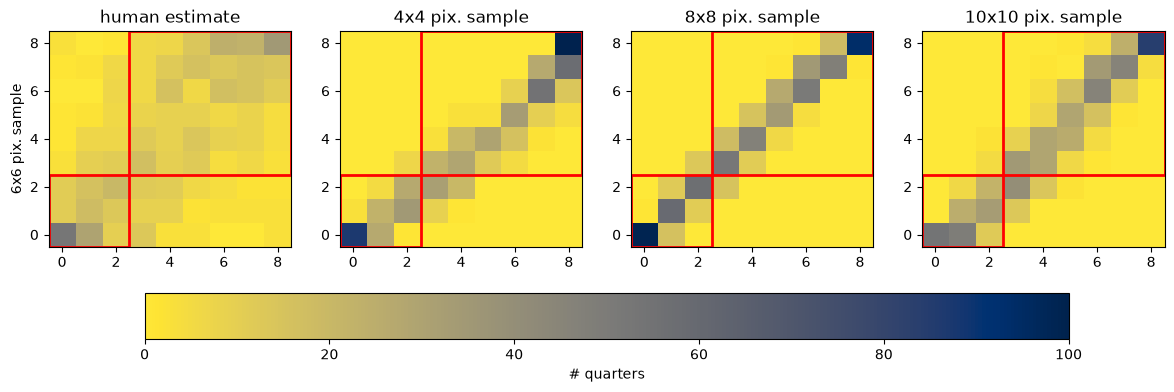

In [23]:
fig = gc.plot_window_comparison(nbq, window_size=window_size, include_human=True)
fig.savefig('compare_windows.png')

### Compare 2015 missing data

In [24]:
mqs_2015 = []
for w in (4, 6, 8, 10):
    try:
        this_mq = pd.read_hdf('missing_2015.h5', key=f'window{w}')
        this_mq.columns = pd.MultiIndex.from_product([[w], this_mq.columns])
        this_mq.columns.names = ['window', 'value']
        mqs_2015.append(this_mq)
    except:
        pass

mq2015 = pd.concat(mqs_2015, axis='columns')

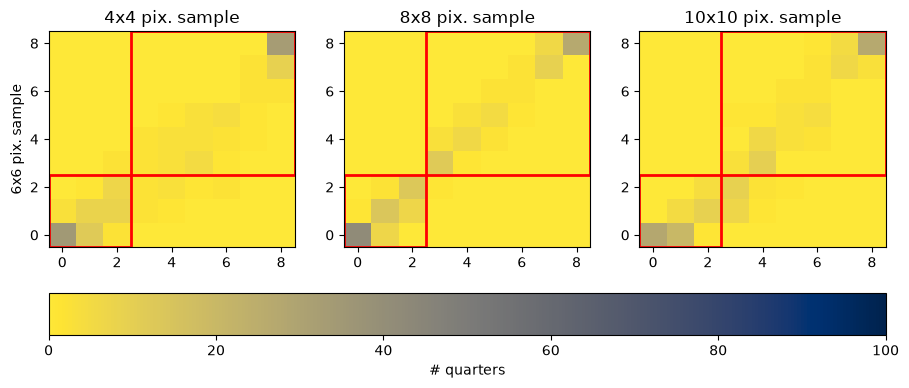

In [25]:
fig = gc.plot_window_comparison(mq2015, window_size=window_size, include_human=False)
fig.savefig('compare_2015_windows.png')

In [26]:
quarter_reports

date  eday  clouds  source            start_iso  \
year month sday quarter                                                         
1975 1     1    1       1975-01-01     2       0    ctio  1975-01-02 01:00:24   
                2       1975-01-01     2       0    ctio  1975-01-02 02:53:32   
                3       1975-01-01     2       0    ctio  1975-01-02 04:46:40   
                4       1975-01-01     2       0    ctio  1975-01-02 06:39:48   
           2    1       1975-01-02     3       0    ctio  1975-01-03 01:00:32   
...                            ...   ...     ...     ...                  ...   
2022 9     3    4       2022-09-03     4       0  blanco  2022-09-04 07:17:47   
           4    1       2022-09-04     5       0  blanco  2022-09-04 23:30:40   
                2       2022-09-04     5       0  blanco  2022-09-05 02:06:07   
                3       2022-09-04     5       0  blanco  2022-09-05 04:41:35   
                4       2022-09-04     5       0  blanco  2022-09-05 07:17:02   

                                     end_iso  
year month sday quarter                       
1975 1     1    1        1975-01-02 02:53:32  
                2        1975-01-02 04:46:40  
                3        1975-01-02 06:39:48  
                4        1975-01-02 08:32:56  
           2    1        1975-01-03 02:53:50  
...                                      ...  
2022 9     3    4        2022-09-04 09:53:40  
           4    1        2022-09-05 02:06:07  
                2        2022-09-05 04:41:35  
                3        2022-09-05 07:17:02  
                4        2022-09-05 09:52:29  

[69652 rows x 6 columns]